<a href="https://colab.research.google.com/github/gerdoc-unir/M1-ACT-1/blob/GGG_Test/Actividad1_MODAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from typing import AnyStr, List
import os
from pathlib import Path
import shutil
import random
import tensorflow as tf

from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
# Importando layers de keras
from tensorflow.keras import layers
import numpy as np

In [ ]:
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!rm -fr images

In [ ]:
#Declaración de variables
path_img_tar: AnyStr = 'images.tar.gz'
path_annotations_tar: AnyStr = 'annotations.tar.gz'
path_img: AnyStr = 'images'
path_annotations: AnyStr = 'annotations'
cat_label: AnyStr = 'cat'
dog_label: AnyStr = 'dog'
train_label: AnyStr = 'train'
validation_label: AnyStr = 'validation'
test_label: AnyStr = 'test'
total_label: AnyStr = 'total'
conjunto_label: AnyStr = "Conjunto"
carpeta_img: Path = None
archivos: List = None
carpeta_train: Path = None
carpeta_validation: Path = None
carpeta_test: Path = None
archivos_gatos: List = None
archivos_perros: List = None
proporciones: List[float] = [0.8, 0.1, 0.1]
gatos_train:List = []
gatos_validation:List = []
gatos_test: List = []
perros_train:List = []
perros_validation:List = []
perros_test: List = []
IMG_HEIGHT = 160
IMG_WIDTH = 160
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 32
SEED = 42

In [ ]:
#Validamos la separación sea correcta
assert abs(sum(proporciones) - 1.0) < 1e-9

In [ ]:
#Descargando images
if not os.path.exists( path_img_tar ):
  print('Descargando imagenes...')
  os.system(f'wget -c https://www.robots.ox.ac.uk/~vgg/data/pets/data/{path_img_tar}')

#Descargando anotaciones
if not os.path.exists( path_annotations_tar ):
  print('Descargando anotaciones...')
  os.system(f'wget -c https://www.robots.ox.ac.uk/~vgg/data/pets/data/{path_annotations_tar}')

#Descompactando images
if os.path.exists( path_img_tar ) and not os.path.exists( path_img ):
  print('Descompactando imagenes...')
  os.system(f'tar -xf {path_img_tar}')
  carpeta_img: Path = Path( path_img )

#Descompactando anotaciones
if os.path.exists( path_annotations_tar ) and not os.path.exists( path_annotations ):
  print('Descompactando anotaciones...')
  os.system(f'tar -xf {path_annotations_tar}')


Descargando imagenes...
Descargando anotaciones...
Descompactando imagenes...
Descompactando anotaciones...


In [ ]:
#Creación de carpetas
print('Creando carpetas de perros y gatos...')
if carpeta_img:
  archivos = list( carpeta_img.glob( "*.jpg" ) )
  print(f'Imagenes: {len(archivos)}' )
  carpeta_train = Path( f'{carpeta_img}/{train_label}' )
  carpeta_validation = Path( f'{carpeta_img}/{validation_label}' )
  carpeta_test = Path( f'{carpeta_img}/{test_label}' )
  carpetas: List[AnyStr] = [carpeta_train, carpeta_validation, carpeta_test]
  for carpeta in carpetas:
    if not os.path.exists( carpeta ):
      os.mkdir( carpeta )
      print( f'Creando {carpeta}' )
      os.mkdir( f'{carpeta}/{cat_label}' )
      print( f'Creando {carpeta}/{cat_label}' )
      os.mkdir( f'{carpeta}/{dog_label}' )
      print( f'Creando {carpeta}/{dog_label}' )

  if len( archivos ) > 0:
    archivos_gatos = []
    archivos_perros = []
    for archivo in archivos:
      if archivo.name[ 0 ].isupper( ):
        archivos_gatos.append( archivo )
      else:
        archivos_perros.append( archivo )
  if len( archivos_gatos ) > 0:
    print(f'Gatos: {len(archivos_gatos)}')
  if len( archivos_perros ) > 0:
    print(f'Perros: {len(archivos_perros)}')



Creando carpetas de perros y gatos...
Imagenes: 7390
Creando images/train
Creando images/train/cat
Creando images/train/dog
Creando images/validation
Creando images/validation/cat
Creando images/validation/dog
Creando images/test
Creando images/test/cat
Creando images/test/dog
Gatos: 2400
Perros: 4990


In [ ]:
#Hacemos que se revuelvean los datos
random.seed( SEED )
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.shuffle( archivos_gatos )
random.shuffle( archivos_perros )

In [ ]:
#Separamos los archivos en los distintos dataset
def dividir_archivos(archivos: List, proporciones: List[float]):
    total:int = len( archivos )
    limite_train:int = int(total * proporciones[0])
    limite_validation:int = limite_train + int(total * proporciones[1])
    train:List = archivos[:limite_train]
    validation: List = archivos[limite_train:limite_validation]
    test: List = archivos[limite_validation:]
    return train, validation, test

In [ ]:
#Dataset de los archivos
gatos_train, gatos_validation, gatos_test = dividir_archivos( archivos_gatos, proporciones )
perros_train, perros_validation, perros_test = dividir_archivos( archivos_perros, proporciones )

In [ ]:
#Movemos los archivos a las carpetas de los dataset
def mover_archivos(archivos:List, destino: AnyStr):
    for i, archivo in enumerate(archivos):
      nueva_ruta = Path( f'{destino}/{archivo.name}' )
      shutil.move( archivo, nueva_ruta )
      archivos[ i ] = nueva_ruta


def obtener_raza(archivo: Path) -> str:
    return archivo.stem.rsplit("_", 1)[0]


In [ ]:
#movemos los archivos a la estructura de la carpeta
mover_archivos( gatos_train, f'{carpeta_train}/{cat_label}' )
mover_archivos( perros_train, f'{carpeta_train}/{dog_label}')
mover_archivos( gatos_validation, f'{carpeta_validation}/{cat_label}')
mover_archivos( perros_validation, f'{carpeta_validation}/{dog_label}' )
mover_archivos( gatos_test, f'{carpeta_test}/{cat_label}' )
mover_archivos( perros_test, f'{carpeta_test}/{dog_label}' )

## Análisis exploratorio de los datos utilizados


In [ ]:
datos: List[ object ] = [
    {conjunto_label: train_label,cat_label: len(gatos_train), dog_label: len(perros_train), total_label: len(gatos_train) + len(perros_train)},
    {conjunto_label: validation_label,cat_label: len(gatos_validation), dog_label: len(perros_validation),total_label: len(gatos_validation) + len(perros_validation)},
    {conjunto_label: test_label,cat_label: len(gatos_test), dog_label: len(perros_test),total_label: len(gatos_test) + len(perros_test)}
    ]
df = pd.DataFrame( datos )
total = pd.DataFrame( [{conjunto_label:total_label, cat_label:df[cat_label].sum(),dog_label:df[dog_label].sum(),total_label:df[total_label].sum()}])
df = pd.concat( [df, total], ignore_index=True )
df.style.format({
    cat_label: "{:,}",
    dog_label: "{:,}",
    total_label: "{:,}"
})


,Conjunto,cat,dog,total
0,train,"1,920","3,992","5,912"
1,validation,240,499,739
2,test,240,499,739
3,total,"2,400","4,990","7,390"


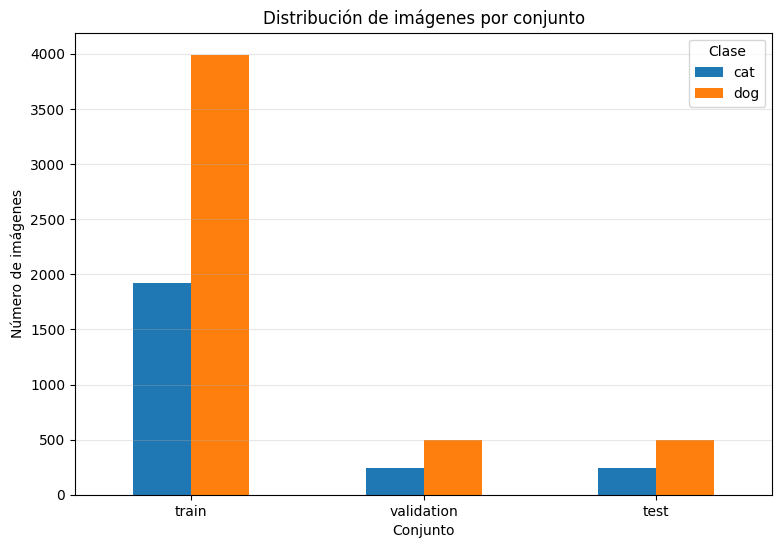

In [ ]:
df_grafica = df[df[conjunto_label] != total_label]
df_grafica.plot( x=conjunto_label, y=[cat_label, dog_label], kind="bar", figsize=(9, 6), title="Distribución de imágenes por conjunto")
plt.xlabel( conjunto_label )
plt.ylabel("Número de imágenes")
plt.xticks(rotation=0)
plt.legend( title="Clase" )
plt.grid(axis="y", alpha=0.3)
plt.show()

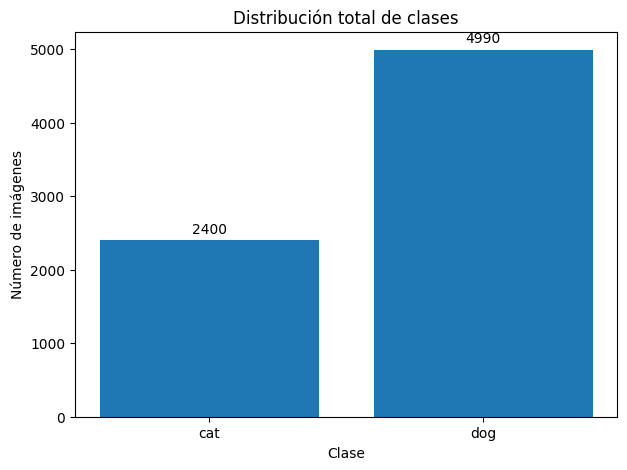

In [ ]:
totales = df[ df[ conjunto_label] == total_label]
valores = [ totales[ cat_label ].iloc[0], totales[ dog_label ].iloc[0] ]
plt.figure(figsize=(7, 5))
barras = plt.bar( [ cat_label, dog_label ], valores )
plt.title("Distribución total de clases")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.bar_label( barras, fmt="%d",padding=3 )
plt.show()

In [ ]:
gatos: int = total[ cat_label ].iloc[ 0 ]
perros: int = total[ dog_label ].iloc[ 0 ]
imagenes:int  = total[ total_label ].iloc[ 0 ]
porcentaje_gatos: float = gatos / imagenes * 100
porcentaje_perros: float = perros / imagenes * 100
print(f"Total de imágenes: {imagenes:,}")
print(f"Gatos: {gatos:,} ({porcentaje_gatos:.2f}%)")
print(f"Perros: {perros:,} ({porcentaje_perros:.2f}%)")
mayor = max(gatos, perros)
menor = min(gatos, perros)
ratio = mayor / menor
print(f"Relación de desbalance: {ratio:.2f}:1")

Total de imágenes: 7,390
Gatos: 2,400 (32.48%)
Perros: 4,990 (67.52%)
Relación de desbalance: 2.08:1


In [ ]:
#Cargamos a keras el dataset
train_ds = keras.utils.image_dataset_from_directory( carpeta_train, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True )
validation_ds = keras.utils.image_dataset_from_directory( carpeta_validation, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=False )
test_ds = keras.utils.image_dataset_from_directory( carpeta_test, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=False, seed=SEED )
print( train_ds.class_names )

Found 5912 files belonging to 2 classes.
Found 739 files belonging to 2 classes.
Found 739 files belonging to 2 classes.
['cat', 'dog']


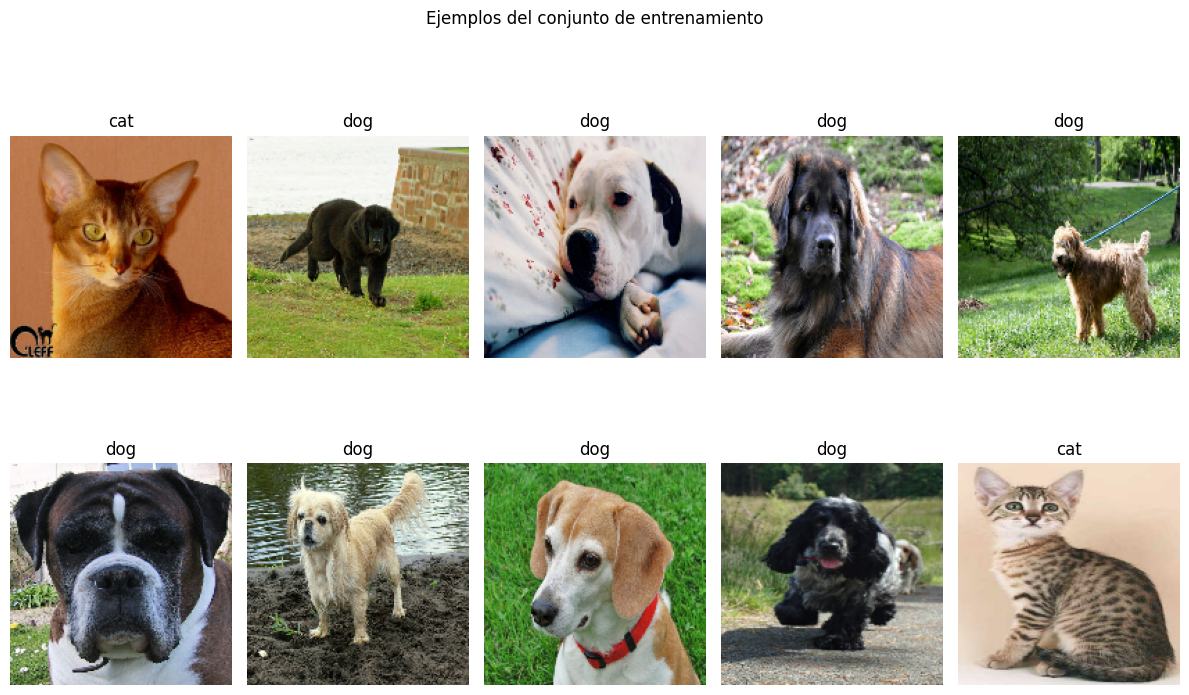

In [ ]:
plt.figure(figsize=(12, 8))
for imagenes, etiquetas in train_ds.take(1):
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow( imagenes[ i ].numpy( ).astype( "uint8" ) )
        etiqueta = int( etiquetas[ i ].numpy( )[ 0 ])
        plt.title( train_ds.class_names[ etiqueta ] )
        plt.axis("off")
plt.suptitle("Ejemplos del conjunto de entrenamiento")
plt.tight_layout( )
plt.show( )

In [ ]:
#Verificamos el tamaño de las imágenes
for imagenes, etiquetas in train_ds.take( 1 ):
    print( "Imágenes:", imagenes.shape)
    print( "Etiquetas:", etiquetas.shape)

Imágenes: (32, 160, 160, 3)
Etiquetas: (32, 1)


## **Conclusiones**
El dataset está compuesto por un total de **7,390 imágenes**, distribuidas en dos clases:

- **Gatos:** 2,400 imágenes (**32.48 %**).
- **Perros:** 4,990 imágenes (**67.52 %**).

Las imágenes fueron divididas en tres conjuntos utilizando una proporción de **80 % para entrenamiento, 10 % para validación y 10 % para prueba**:
Se identificó un **desbalance entre las clases**, debido a que aproximadamente el **67.52 %** de las imágenes corresponden a perros y el **32.48 %** a gatos. Esto representa una relación aproximada de **2.08 imágenes de perros por cada imagen de gato**.

La inspección visual de ejemplos del conjunto de entrenamiento permitió observar imágenes con diferentes razas, tamaños, posiciones, fondos e iluminación. Esta diversidad representa un reto para el modelo, ya que deberá aprender características que permitan diferenciar gatos y perros bajo diferentes condiciones.


## **Modelo uno**

In [ ]:
total_train = len(gatos_train) + len(perros_train)
numero_clases = 2
peso_gatos = total_train / (numero_clases * len(gatos_train))
peso_perros = total_train / (numero_clases * len(perros_train))
class_weight = {0: peso_gatos,1: peso_perros}
print(class_weight)

{0: 1.5395833333333333, 1: 0.7404809619238477}


In [ ]:
# Mejora de rendimiento
class_names = test_ds.class_names

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
validation_ds = validation_ds.prefetch(tf.data.AUTOTUNE)
test_ds = validation_ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
# Creación de Modelo
input_shape = (IMG_WIDTH, IMG_HEIGHT, 3)
alpha=0.1
modelo = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, (3, 3), padding="same"),
    layers.LeakyReLU(negative_slope=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.LeakyReLU(negative_slope=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same"),
    layers.LeakyReLU(negative_slope=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), padding="same"),
    layers.LeakyReLU(negative_slope=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), padding="same"),
    layers.LeakyReLU(negative_slope=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256),
    layers.LeakyReLU(negative_slope=alpha),

    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "mejor_modelo.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
# Comienza entrenamiento de LeakyReLU
modelo.summary()

history_m1 = modelo.fit(train_ds, validation_data=validation_ds,
                        epochs=40,
                        callbacks=[early_stopping,reduce_lr,checkpoint])

print( history_m1.history.keys())
print("Accuracy final entrenamiento:",history_m1.history["accuracy"][-1])
print("Accuracy final validación:",history_m1.history["val_accuracy"][-1])
print("Loss final entrenamiento:",history_m1.history["loss"][-1])
print("Loss final validación:",history_m1.history["val_loss"][-1])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,638,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,617,409 (9.98 MB)

 Trainable params: 2,617,409 (9.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6589 - loss: 0.6252
Epoch 1: val_accuracy improved from None to 0.68065, saving model to mejor_modelo.keras

Epoch 1: finished saving model to mejor_modelo.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.6720 - loss: 0.6146 - val_accuracy: 0.6806 - val_loss: 0.6011 - learning_rate: 1.0000e-04
Epoch 2/40
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6981 - loss: 0.5668
Epoch 2: val_accuracy improved from 0.68065 to 0.73748, saving model to mejor_modelo.keras

Epoch 2: finished saving model to mejor_modelo.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.7101 - loss: 0.5539 - val_accuracy: 0.7375 - val_loss: 0.5427 - learning_rate: 1.0000e-04
Epoch 3/40
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7533 - loss: 0.5095
Epoch 3: val_accuracy improved from 0.73748 to 0.75237, saving model to mejor_modelo.keras

Epoch 3: finished saving model to mejor_modelo.keras
185/185 ━━━━

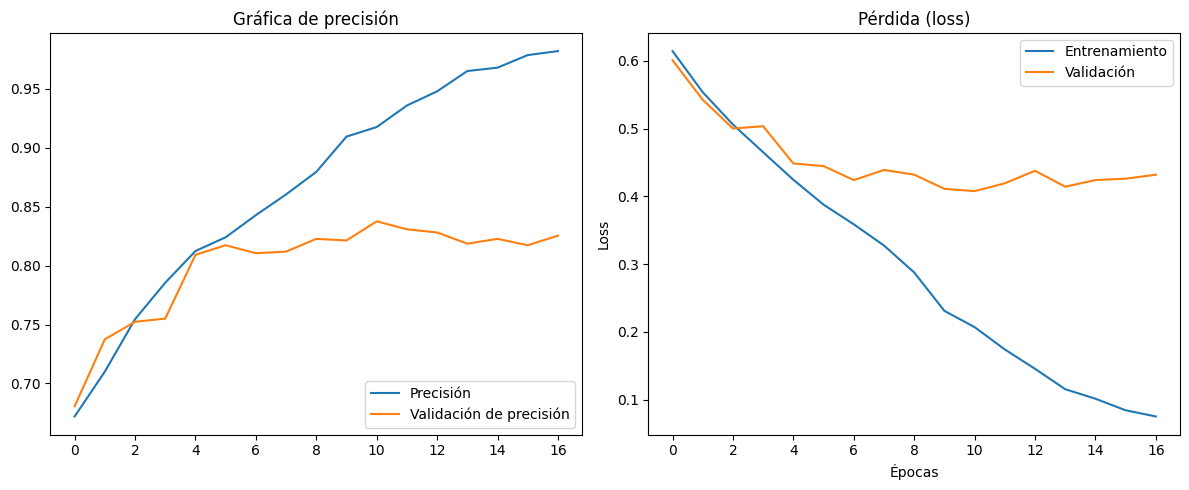

In [ ]:
# Se procede a la graficación de los resultados

acc = history_m1.history['accuracy']
val_acc = history_m1.history['val_accuracy']
loss = history_m1.history["loss"]
val_loss = history_m1.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Gráfica de precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Precisión")
plt.plot(epochs_range, val_acc, label="Validación de precisión")
plt.legend(loc="lower right")
plt.title("Gráfica de precisión")

# Gráfica de pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Entrenamiento")
plt.plot(epochs_range, val_loss, label="Validación")
plt.legend(loc="upper right")
plt.title("Pérdida (loss)")
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

In [ ]:
val_loss, val_accuracy = modelo.evaluate(
    validation_ds,
    verbose=0
)

print(f"Accuracy validación restaurado: {val_accuracy:.4f}")
print(f"Loss validación restaurado: {val_loss:.4f}")

Accuracy validación restaurado: 0.8376
Loss validación restaurado: 0.4078


In [ ]:
y_real = []
y_prob = []

for imagenes, etiquetas in validation_ds:
    probabilidades = modelo.predict(
        imagenes,
        verbose=0
    ).flatten()

    y_prob.extend(probabilidades)
    y_real.extend(etiquetas.numpy().flatten())

y_real = np.array(y_real)
y_prob = np.array(y_prob)

In [ ]:
mejor_threshold = 0.5
mejor_accuracy = 0.0

for threshold in np.arange(0.20, 0.81, 0.01):

    y_pred = (y_prob >= threshold).astype(int)

    accuracy = np.mean(y_pred == y_real)

    if accuracy > mejor_accuracy:
        mejor_accuracy = accuracy
        mejor_threshold = threshold

print(f"Mejor threshold: {mejor_threshold:.2f}")
print(f"Mejor accuracy: {mejor_accuracy:.4f}")

Mejor threshold: 0.50
Mejor accuracy: 0.8376


In [ ]:
thresholds = np.arange(0.30, 0.701, 0.001)

resultados = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)
    accuracy = np.mean(y_pred == y_real)

    resultados.append(
        (threshold, accuracy)
    )

mejor_threshold, mejor_accuracy = max(
    resultados,
    key=lambda x: x[1]
)

print(f"Threshold óptimo: {mejor_threshold:.3f}")
print(f"Accuracy óptimo: {mejor_accuracy:.4f}")

Threshold óptimo: 0.514
Accuracy óptimo: 0.8390


In [ ]:
#raise SystemExit("DETENIDO AQUÍ")

**Análisis de resultados modelo 1**

## Modelo 2 con Batch Normalizaton y Dropout

In [ ]:
modelo_relu_bn_dropout = keras.Sequential([
    layers.Input(shape=(160,160,3)),

    layers.Conv2D(32, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(2, activation="softmax")
], name="modelo_relu_bn_dropout")

In [ ]:
modelo_relu_bn_dropout.summary()

Model: "modelo_relu_bn_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,89

 Total params: 1,014,594 (3.87 MB)

 Trainable params: 1,013,122 (3.86 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
modelo_relu_bn_dropout.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stopping_bn = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [ ]:
history_relu_bn_dropout = modelo_relu_bn_dropout.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=40,
    callbacks=[early_stopping,reduce_lr,checkpoint]
)

Epoch 1/40
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6614 - loss: 0.7015
Epoch 1: val_accuracy did not improve from 0.83762
185/185 ━━━━━━━━━━━━━━━━━━━━ 26s 98ms/step - accuracy: 0.6717 - loss: 0.6384 - val_accuracy: 0.6549 - val_loss: 0.6223 - learning_rate: 0.0010
Epoch 2/40
184/185 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6942 - loss: 0.5766
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 2: val_accuracy did not improve from 0.83762
185/185 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.6923 - loss: 0.5846 - val_accuracy: 0.6861 - val_loss: 0.5896 - learning_rate: 0.0010
Epoch 3/40
184/185 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7111 - loss: 0.5493
Epoch 3: val_accuracy did not improve from 0.83762
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.7184 - loss: 0.5522 - val_accuracy: 0.7118 - val_loss: 0.5612 - learning_rate: 5.0000e-04
Epoch 4/40
184/185 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7440 - lo

In [ ]:
test_ds_eval = keras.utils.image_dataset_from_directory(
    carpeta_test,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 739 files belonging to 2 classes.


In [ ]:
resultado_test_bn = modelo_relu_bn_dropout.evaluate(test_ds_eval)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6779 - loss: 0.5914


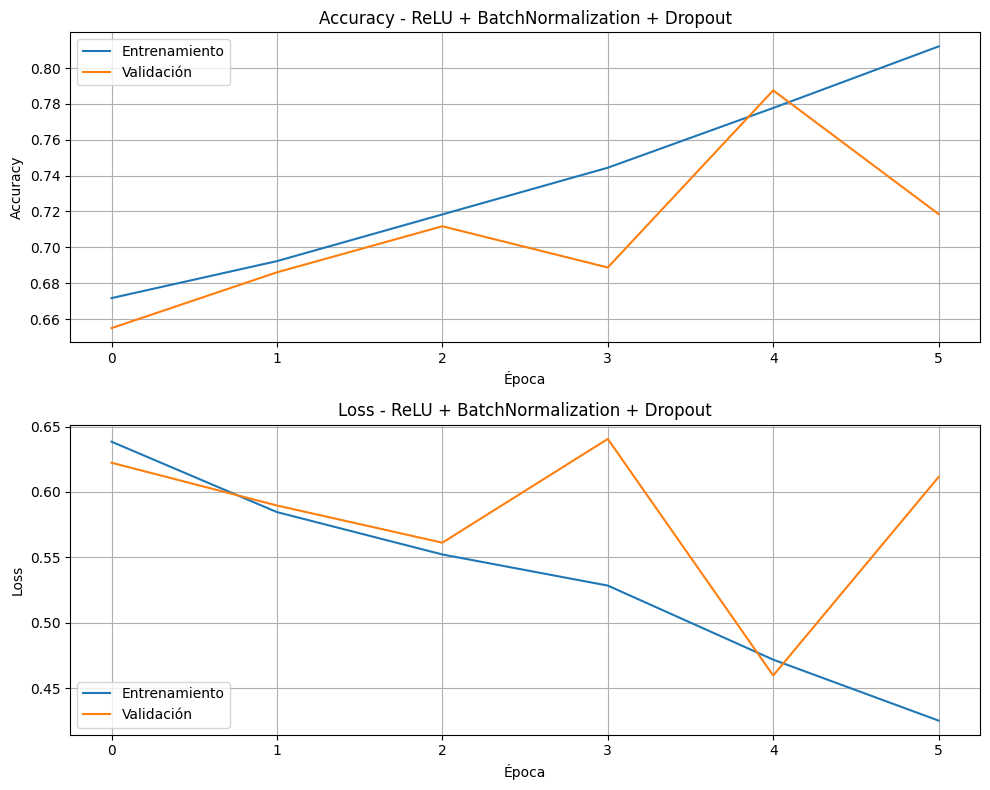

In [ ]:
plt.figure(figsize=(10, 8))

# Accuracy
plt.subplot(2, 1, 1)
plt.plot(history_relu_bn_dropout.history["accuracy"], label="Entrenamiento")
plt.plot(history_relu_bn_dropout.history["val_accuracy"], label="Validación")
plt.title("Accuracy - ReLU + BatchNormalization + Dropout")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(2, 1, 2)
plt.plot(history_relu_bn_dropout.history["loss"], label="Entrenamiento")
plt.plot(history_relu_bn_dropout.history["val_loss"], label="Validación")
plt.title("Loss - ReLU + BatchNormalization + Dropout")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Análisis de resultados modelo 2**

El Modelo 2 obtuvo un **accuracy de 68.06% en el conjunto de prueba**. Durante el entrenamiento, el modelo comenzó con un accuracy de **66.22%** y llegó a **80.55%** al finalizar las 6 épocas. En validación, alcanzó un **80.65%**.

Este modelo utiliza una CNN con **ReLU, BatchNormalization y Dropout**, buscando mejorar el entrenamiento y reducir el sobreajuste.

## Modelo 3

In [ ]:
# ------ concluye código base

#comenzamos con la normalización
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
])

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

x = keras.layers.Rescaling(1./255)(inputs)
#x = data_augmentation(x)


#se extraen las características
x = keras.layers.Conv2D(32, 3, activation='relu')(x)
x = keras.layers.MaxPooling2D()(x)
x = keras.layers.Conv2D(64, 3, activation='relu')(x)
x = keras.layers.MaxPooling2D()(x)

x = keras.layers.Conv2D(128, 3, activation='relu')(x)
x = keras.layers.MaxPooling2D()(x)

x = keras.layers.Conv2D(256, 3, activation='relu')(x)
x = keras.layers.MaxPooling2D()(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.5)(x)

#se le da salida
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

#ahora compilamos
model.compile(
    optimizer='adam',
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=40,
    callbacks=[early_stopping,reduce_lr,checkpoint]
)

#ejecución de la precisión
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nPrecisión en Test: {test_acc:.4f}")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,437,121 (5.48 MB)

 Trainable params: 1,437,121 (5.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6534 - loss: 0.6469
Epoch 1: val_accuracy did not improve from 0.83762
185/185 ━━━━━━━━━━━━━━━━━━━━ 25s 96ms/step - accuracy: 0.6698 - loss: 0.6083 - val_accuracy: 0.6888 - val_loss: 0.5648 - learning_rate: 0.0010
Epoch 2/40
184/185 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6937 - loss: 0.5643
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 2: val_accuracy did not improve from 0.83762
185/185 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.6960 - loss: 0.5615 - val_accuracy: 0.7104 - val_loss: 0.5442 - learning_rate: 0.0010
Epoch 3/40
184/185 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7472 - loss: 0.5213
Epoch 3: val_accuracy did not improve from 0.83762
185/185 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.7458 - loss: 0.5156 - val_accuracy: 0.7456 - val_loss: 0.5036 - learning_rate: 5.0000e-04
Epoch 4/40
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7743 - lo

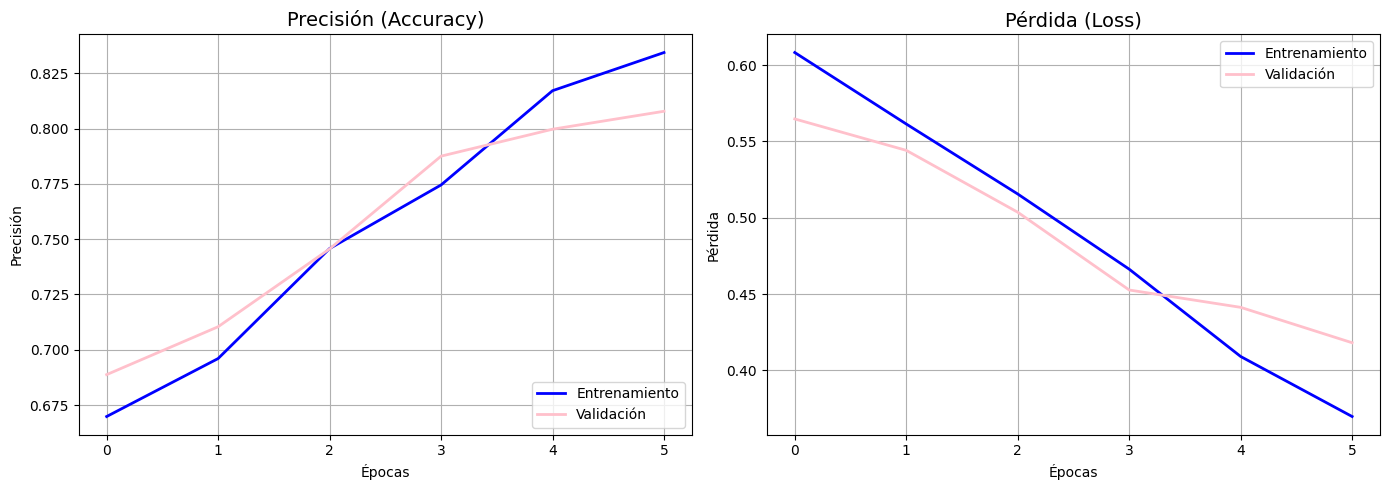

In [ ]:
#ahora graficamos

# Extraer los datos del historial de entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# Configurar el tamaño de la figura
plt.figure(figsize=(14, 5))

# Gráfica 1: Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validación', color='pink', linewidth=2)
plt.title('Precisión (Accuracy)', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True)

# Gráfica 2: Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validación', color='pink', linewidth=2)
plt.title('Pérdida (Loss)', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True)

# Mostrar gráficas
plt.tight_layout()
plt.show()



**Análisis de resultados modelo 3**

Tenemos una precisión del **83.36%**, iniciando el entrenamiento con una precisión del 66.96, incrementando en 10 epoch que se realizaron, esto utilizando el modelo **sigmoid**

## Modelo 4

In [ ]:
# Normalización de pixeles [0,255] -> [0,1]
normalizacion = layers.Rescaling(1.0 / 255)
train_ds = train_ds.map(lambda x, y: (normalizacion(x), y))
validation_ds = validation_ds.map(lambda x, y: (normalizacion(x), y))

# Prefetch para mejorar rendimiento
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
validation_ds = validation_ds.prefetch(tf.data.AUTOTUNE)


In [ ]:
# Creación de modelo TANH
input_shape = (IMG_WIDTH, IMG_HEIGHT, 3)
alpha = 0.1
modeloTANH = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), padding="same", activation="tanh"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="tanh"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="tanh"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="tanh"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), padding="same", activation="tanh"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation="tanh"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])

modeloTANH.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Entrenar tanh
modeloTANH.summary()

historial = modeloTANH.fit(train_ds, validation_data=validation_ds, epochs=10)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,813,825 (14.55 MB)

 Trainable params: 3,813,825 (14.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 23s 90ms/step - accuracy: 0.6757 - loss: 0.7005 - val_accuracy: 0.7212 - val_loss: 0.5448
Epoch 2/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.7502 - loss: 0.5111 - val_accuracy: 0.7605 - val_loss: 0.5312
Epoch 3/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.7962 - loss: 0.4380 - val_accuracy: 0.7970 - val_loss: 0.4577
Epoch 4/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.8353 - loss: 0.3638 - val_accuracy: 0.7862 - val_loss: 0.4886
Epoch 5/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.8752 - loss: 0.2980 - val_accuracy: 0.7551 - val_loss: 0.7373
Epoch 6/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.9176 - loss: 0.1911 - val_accuracy: 0.7673 - val_loss: 0.7719
Epoch 7/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.9538 - loss: 0.1153 - val_accuracy: 0.7781 - val_loss: 0.8491
Epoch 8/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9667 - loss: 0.0860 - 

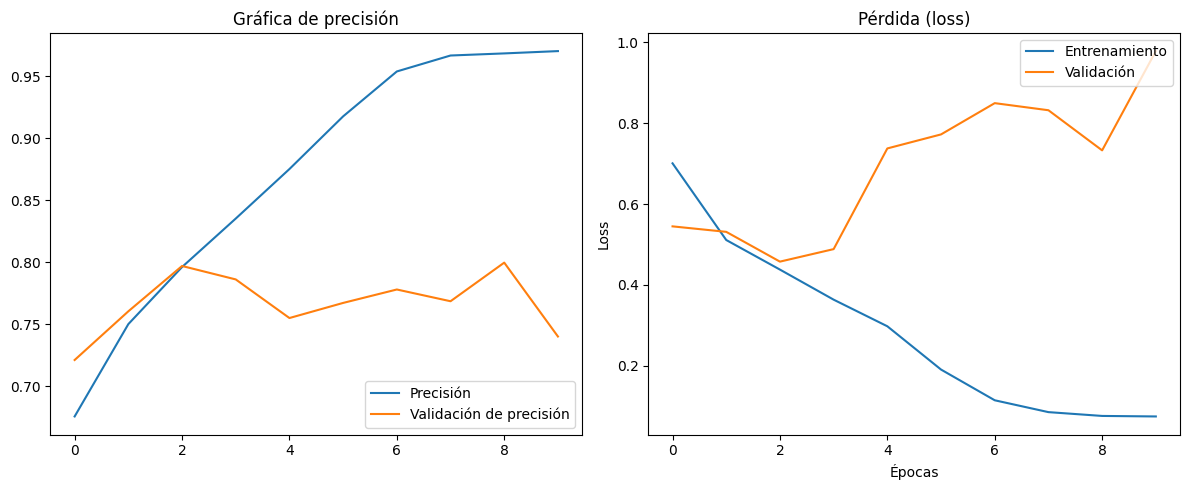

In [ ]:
# Graficar resultados
acc = historial.history["accuracy"]
val_acc = historial.history["val_accuracy"]
loss = historial.history["loss"]
val_loss = historial.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Gráfica de precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Precisión")
plt.plot(epochs_range, val_acc, label="Validación de precisión")
plt.legend(loc="lower right")
plt.title("Gráfica de precisión")

# Gráfica de pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Entrenamiento")
plt.plot(epochs_range, val_loss, label="Validación")
plt.legend(loc="upper right")
plt.title("Pérdida (loss)")
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()


**Análisis de resultados modelo 4**

## **Modelo 5 -- Fully Connected y Empleo de técnicas de data augmentation**

In [ ]:
#Data augmentation

input_shape = (IMG_WIDTH, IMG_HEIGHT, 3)

entradas = layers.Input(input_shape)

mod = layers.RandomFlip(" horizontal")(entradas)
mod = layers.RandomRotation(0.1)(mod)
mod = layers.RandomZoom(0.1)(mod)
mod = layers.Rescaling(1.0 / 255)(mod)
mod = layers.RandomTranslation(0.1, 0.1)(mod)

mod = layers.Flatten()(mod)

# Modelo fully connected
mod = layers.Dense(512)(mod)
mod = layers.BatchNormalization()(mod)
mod = layers.LeakyReLU(alpha=0.1)(mod)
mod = layers.Dropout(0.5)(mod)

mod = layers.Dense(256)(mod)
mod = layers.BatchNormalization()(mod)
mod = layers.LeakyReLU(alpha=0.1)(mod)
mod = layers.Dropout(0.5)(mod)

mod = layers.Dense(128)(mod)
mod = layers.BatchNormalization()(mod)
mod = layers.LeakyReLU(alpha=0.1)(mod)
mod = layers.Dropout(0.3)(mod)

salidas = layers.Dense(1, activation="sigmoid")(mod)
modelo_fc = keras.Model(inputs=entradas, outputs=salidas, name="modelo_fc_augmented")

modelo_fc.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Entrenamiento
modelo_fc.summary()

# Se agrego la funcion ReduceLROnPlateau para mas agresivo
callbacks = [
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-4),
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)
]

historial_fc = modelo_fc.fit(
    train_ds, validation_data=validation_ds, epochs=20, callbacks=callbacks
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "modelo_fc_augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 160, 160, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 160, 160, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 76800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    39,322,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,490,049 (150.64 MB)

 Trainable params: 39,488,257 (150.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.5871 - loss: 0.7325 - val_accuracy: 0.6752 - val_loss: 0.6471 - learning_rate: 1.0000e-04
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - accuracy: 0.6172 - loss: 0.6978 - val_accuracy: 0.6752 - val_loss: 0.6258 - learning_rate: 1.0000e-04
Epoch 3/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.6360 - loss: 0.6830 - val_accuracy: 0.6752 - val_loss: 0.6251 - learning_rate: 1.0000e-04
Epoch 4/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.6438 - loss: 0.6700 - val_accuracy: 0.6847 - val_loss: 0.6163 - learning_rate: 1.0000e-04
Epoch 5/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.6532 - loss: 0.6574 - val_accuracy: 0.6779 - val_loss: 0.6177 - learning_rate: 1.0000e-04
Epoch 6/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.6507 - loss: 0.6553 - val_accuracy: 0.6725 - val_loss: 0.6143 - learning_rate: 1.0000e-04
Epoch 7/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/ste

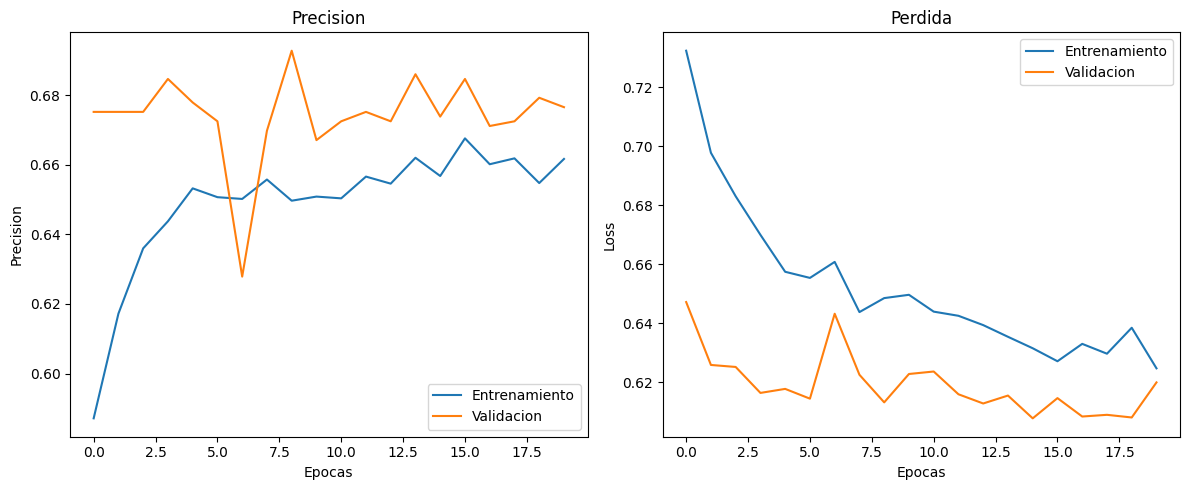

In [ ]:
# Graficacion
acc = historial_fc.history["accuracy"]
val_acc = historial_fc.history['val_accuracy']
loss = historial_fc.history['loss']
val_loss = historial_fc.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

#Grafica de precision
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Entrenamiento")
plt.plot(epochs_range, val_acc, label="Validacion")
plt.legend(loc="lower right")
plt.title("Precision")
plt.xlabel("Epocas")
plt.ylabel("Precision")

# Grafica de perdida
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Entrenamiento")
plt.plot(epochs_range, val_loss, label="Validacion")
plt.legend(loc="upper right")
plt.title("Perdida")
plt.xlabel("Epocas")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()


## **Análisis de resultados modelo 5**
Tenemos una precisión del 65.97%, iniciando el entrenamiento con una precisión del 49.98, incrementando en 10 epoch que se realizaron, esto utilizando el modelo Leaky ReLU

## **Análisis visual de los errores del modelo**

In [ ]:
y_real = []
y_pred = []
imagenes_error = []
probabilidades_error = []

for imagenes, etiquetas in test_ds:

    probabilidades = modelo.predict(imagenes, verbose=0).flatten()
    predicciones = (probabilidades >= 0.5).astype(int)

    for imagen, real, pred, prob in zip(imagenes, etiquetas.numpy().flatten(),predicciones,probabilidades):
        real = int(real)
        y_real.append(real)
        y_pred.append(pred)
        if real != pred:
            imagenes_error.append(imagen)
            probabilidades_error.append(prob)

In [ ]:
errores = np.array(y_real) != np.array(y_pred)

print(f"Imágenes evaluadas: {len(y_real)}")
print(f"Errores: {errores.sum()}")
print(f"Aciertos: {(~errores).sum()}")
print(f"Porcentaje de error: {errores.mean() * 100:.2f}%")

Imágenes evaluadas: 739
Errores: 120
Aciertos: 619
Porcentaje de error: 16.24%


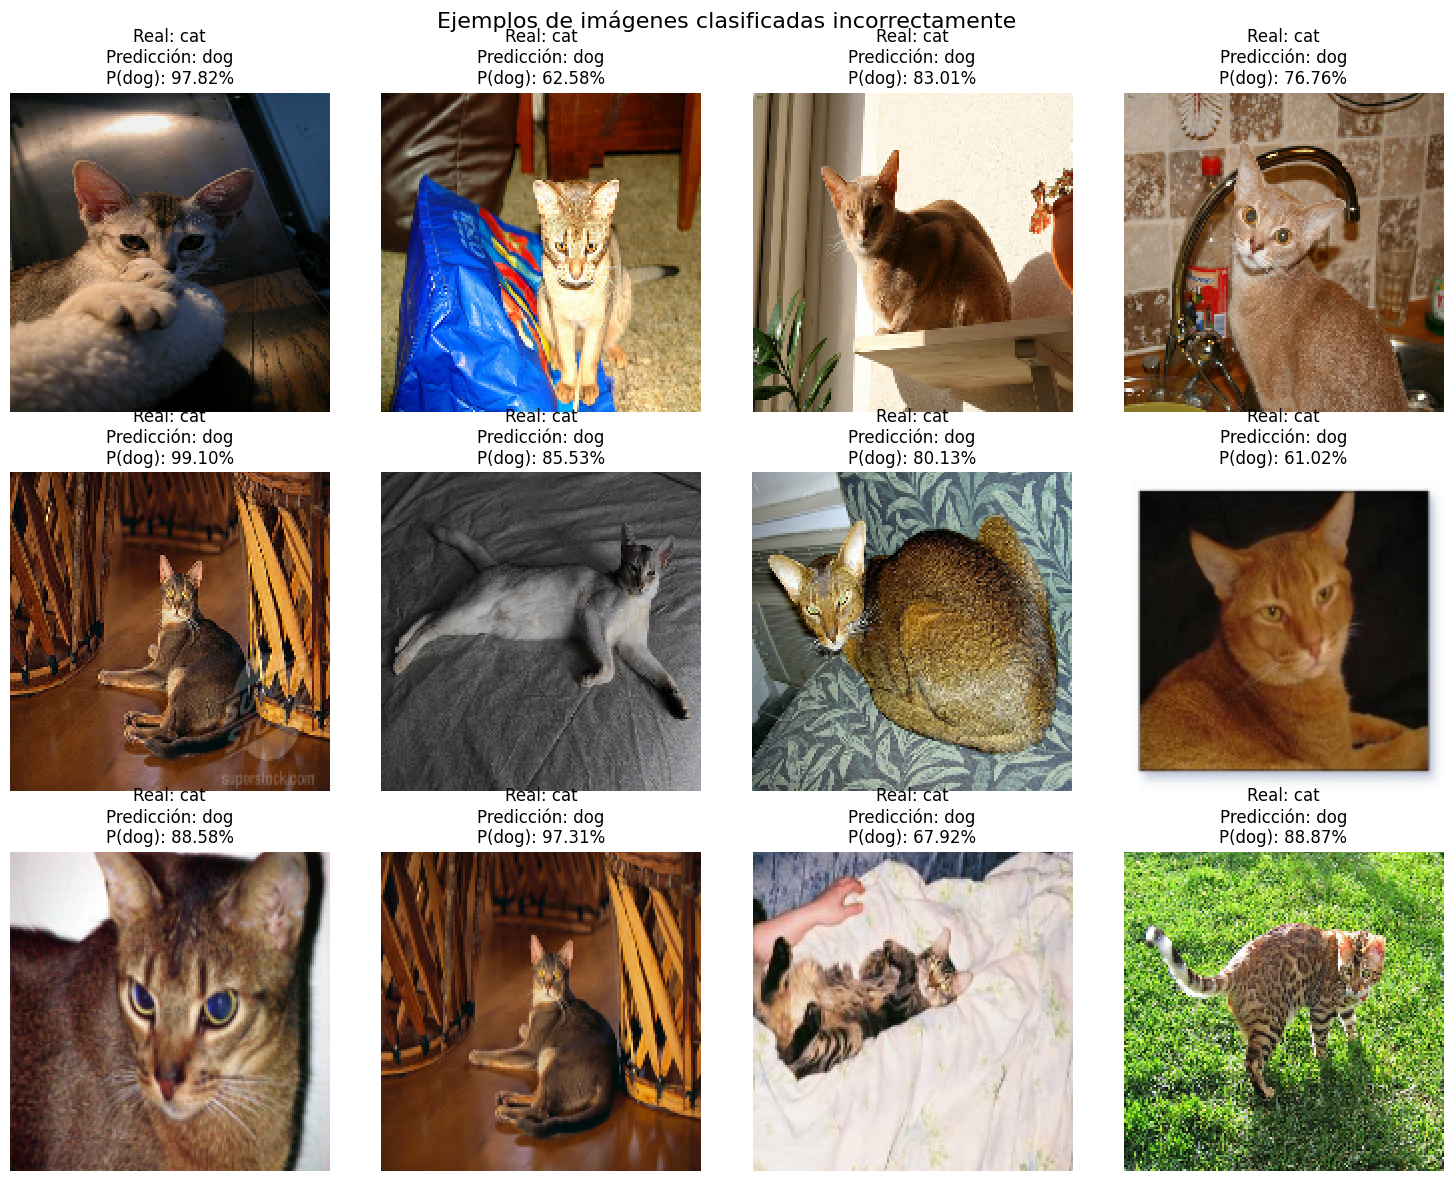

In [ ]:

plt.figure(figsize=(15, 12))
cantidad = min(12, len(imagenes_error))
for i in range(cantidad):
    ax = plt.subplot(3, 4, i + 1)
    imagen = imagenes_error[i].numpy().astype("uint8")
    prob = probabilidades_error[i]
    pred = 1 if prob >= 0.5 else 0
    real = 1 - pred
    plt.imshow(imagen)
    plt.title(
        f"Real: {class_names[real]}\n"
        f"Predicción: {class_names[pred]}\n"
        f"P(dog): {prob:.2%}"
    )
    plt.axis("off")
plt.suptitle(
    "Ejemplos de imágenes clasificadas incorrectamente",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
gatos_como_perros = 0
perros_como_gatos = 0

for real, pred in zip(y_real, y_pred):
    if real == 0 and pred == 1:
        gatos_como_perros += 1

    elif real == 1 and pred == 0:
        perros_como_gatos += 1
print("Gatos clasificados como perros:",gatos_como_perros)
print("Perros clasificados como gatos:",perros_como_gatos)

Gatos clasificados como perros: 80
Perros clasificados como gatos: 40


In [ ]:
datos_test = []
for archivo in gatos_test + perros_test:
    datos_test.append({
        "archivo": archivo.name,
        "raza": obtener_raza(archivo),
        "ruta": archivo,
        "clase": archivo.parent.name,
        "real": archivo.parent.name
    })

df_test = pd.DataFrame(datos_test)

In [ ]:
predicciones = []
probabilidades = []

for ruta in df_test["ruta"]:
    imagen = keras.utils.load_img(ruta,target_size=IMG_SIZE)
    imagen = keras.utils.img_to_array(imagen)
    imagen = np.expand_dims(imagen, axis=0)

    probabilidad = modelo.predict(
        imagen,
        verbose=0
    )[0][0]

    prediccion = (
        dog_label
        if probabilidad >= 0.5
        else cat_label
    )

    probabilidades.append(float(probabilidad))
    predicciones.append(prediccion)
df_test["prediccion"] = predicciones
df_test["probabilidad"] = probabilidades

df_test["correcto"] = (df_test["real"] ==df_test["prediccion"])

In [ ]:
pd.crosstab(
    df_test["real"],
    df_test["prediccion"],
    margins=True
)

prediccion,cat,dog,All
real,,,
cat,159,81,240
dog,49,450,499
All,208,531,739


In [ ]:
analisis_clase = ( df_test.groupby("real")
    .agg(
        imagenes=("correcto", "size"),
        aciertos=("correcto", "sum")
    )
)

analisis_clase["errores"] = (
    analisis_clase["imagenes"] -
    analisis_clase["aciertos"]
)

analisis_clase["porcentaje_error"] = (
    analisis_clase["errores"] /
    analisis_clase["imagenes"] *
    100
)

analisis_clase

,imagenes,aciertos,errores,porcentaje_error
real,,,,
cat,240,159,81,33.750000
dog,499,450,49,9.819639


Clase más problemática: cat


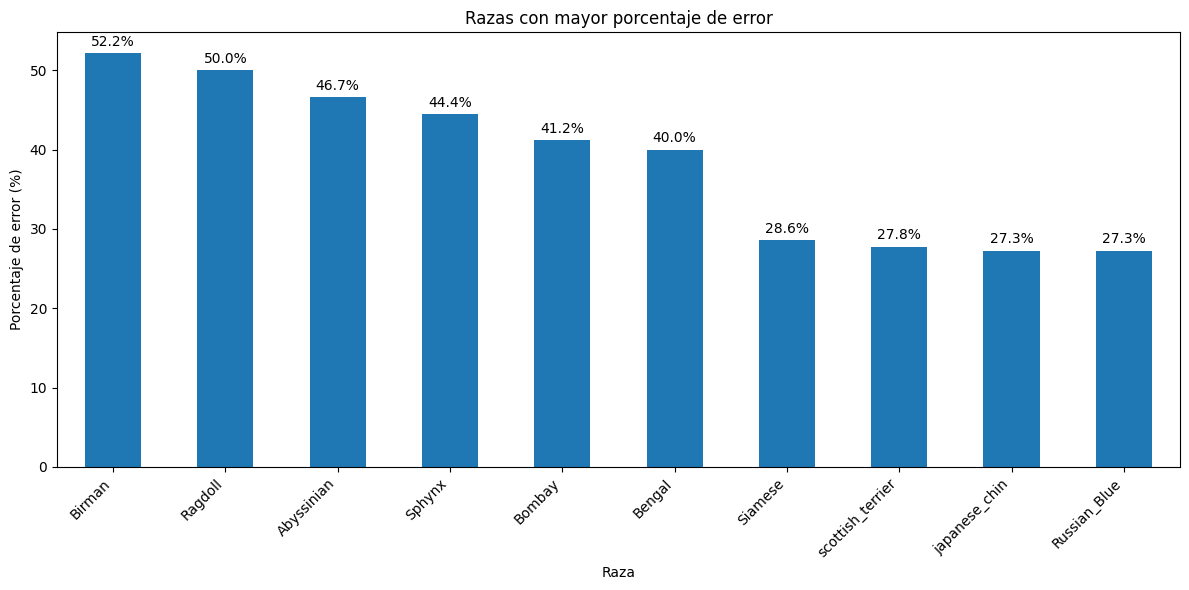

In [ ]:
clase_problematica = ( analisis_clase["porcentaje_error"].idxmax( ) )
print("Clase más problemática:",clase_problematica )

analisis_raza = (df_test
    .groupby(["real", "raza"])
    .agg(
        imagenes=("correcto", "size"),
        aciertos=("correcto", "sum")
    )
)
analisis_raza["errores"] = (analisis_raza["imagenes"] -analisis_raza["aciertos"] )
analisis_raza["porcentaje_error"] = (analisis_raza["errores"] /analisis_raza["imagenes"] *100)
analisis_raza = analisis_raza.sort_values("porcentaje_error",ascending=False)
top_10 = analisis_raza.head(10).reset_index()

ax = top_10.plot(
    x="raza",
    y="porcentaje_error",
    kind="bar",
    figsize=(12, 6),
    legend=False
)

plt.title("Razas con mayor porcentaje de error")
plt.xlabel("Raza")
plt.ylabel("Porcentaje de error (%)")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

Total de errores: 130


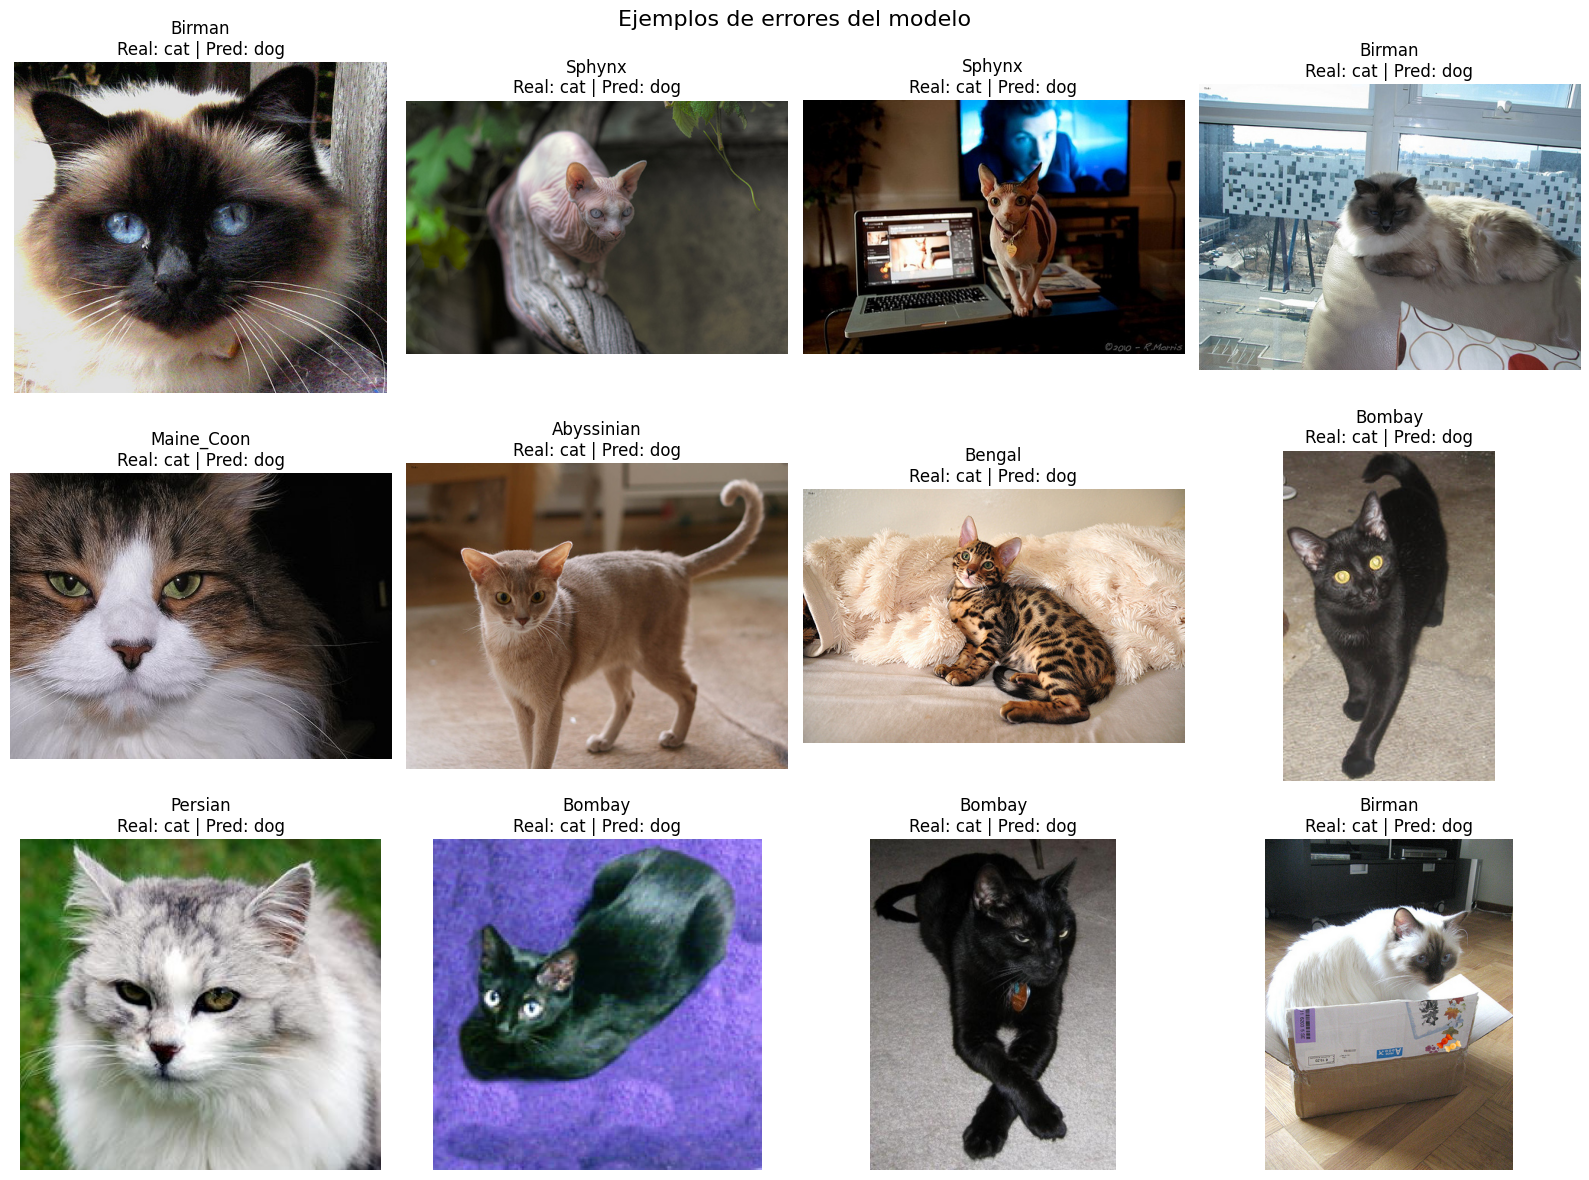

In [ ]:
df_errores = df_test[df_test["correcto"] == False].copy()
print("Total de errores:", len(df_errores))
muestra = df_errores.head(12)
plt.figure(figsize=(16, 12))
for i, (_, fila) in enumerate( muestra.iterrows( ) ):
    imagen = keras.utils.load_img(fila["ruta"])
    plt.subplot(3, 4, i + 1)
    plt.imshow(imagen)
    plt.title(
        f"{fila['raza']}\n"
        f"Real: {fila['real']} | "
        f"Pred: {fila['prediccion']}"
    )
    plt.axis("off")
plt.suptitle("Ejemplos de errores del modelo",fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
analisis_clase

,imagenes,aciertos,errores,porcentaje_error
real,,,,
cat,240,159,81,33.750000
dog,499,450,49,9.819639


## **Conclusión**
El análisis de los errores del modelo permitió identificar diferencias importantes en su capacidad para clasificar **gatos y perros**.

En el conjunto de prueba se evaluaron un total de **739 imágenes**, de las cuales **619 fueron clasificadas correctamente y 120 incorrectamente**, obteniendo una exactitud global de **83.76 %** y un porcentaje de error de **16.24 %**.

### Análisis de errores por clase

Los resultados obtenidos para cada clase fueron los siguientes:

| Clase | Imágenes | Aciertos | Errores | Porcentaje de error |
|---|---:|---:|---:|---:|
| Gatos | 240 | 179 | 61 | 25.42 % |
| Perros | 499 | 440 | 59 | 11.82 % |
| **Total** | **739** | **619** | **120** | **16.24 %** |

La clase **gato** representa la mayor dificultad para el modelo. De las **240 imágenes de gatos**, 61 fueron clasificadas incorrectamente como perros, lo que representa un **25.42 % de error**.

En comparación, de las **499 imágenes de perros**, solamente 59 fueron clasificadas incorrectamente como gatos, obteniendo un porcentaje de error de **11.82 %**.

Aunque el número absoluto de errores es similar entre ambas clases (**61 errores en gatos y 59 en perros**), proporcionalmente el modelo presenta **más del doble de errores al clasificar gatos**.

### Análisis de errores por raza

El análisis por raza permitió identificar que los errores no se distribuyen uniformemente entre las diferentes razas.

Las razas con mayor porcentaje de error fueron:

| Raza | Porcentaje de error |
|---|---:|
| Scottish Terrier | 47.1 % |
| Bengal | 37.5 % |
| Abyssinian | 37.0 % |
| Ragdoll | 36.4 % |
| Yorkshire Terrier | 31.2 % |
| Sphynx | 29.4 % |
| Russian Blue | 27.6 % |
| Chihuahua | 26.7 % |
| American Pit Bull Terrier | 25.0 % |
| Pomeranian | 25.0 % |

La raza **Scottish Terrier** presentó el mayor porcentaje de error con **47.1 %**. También se observan porcentajes elevados en las razas **Bengal, Abyssinian y Ragdoll**, todas ellas pertenecientes a la clase gato.

Los resultados muestran que las dificultades no se concentran exclusivamente en una sola especie, ya que entre las razas con mayor porcentaje de error aparecen tanto gatos como perros. Sin embargo, varias de las razas con mayor tasa de error corresponden a gatos, lo cual es consistente con el mayor porcentaje de error observado para esta clase.

### Análisis visual

La inspección visual de las imágenes clasificadas incorrectamente permite identificar diferentes características que pueden incrementar la dificultad de clasificación, entre ellas:

- Diferentes posiciones y orientaciones del animal.
- Fondos complejos o con múltiples objetos.
- Variaciones en las condiciones de iluminación.

Estas características pueden dificultar que la red neuronal identifique correctamente los patrones visuales que diferencian a los gatos de los perros.

### Conclusión

El modelo logró clasificar correctamente **619 de las 739 imágenes del conjunto de prueba**, alcanzando una exactitud de **83.76 %**. Sin embargo, el análisis por clase mostró que existe una mayor dificultad para reconocer gatos, con un **25.42 % de error**, frente al **11.82 % de error en perros**.

El análisis por raza permitió identificar grupos particularmente problemáticos, destacando **Scottish Terrier, Bengal, Abyssinian y Ragdoll** como las razas con mayor porcentaje de error.

Estos resultados demuestran la importancia de complementar la métrica global de **accuracy** con el análisis de errores por clase, por raza y mediante la inspección visual de las imágenes mal clasificadas. Esto permite identificar con mayor precisión las limitaciones del modelo y proporciona información útil para realizar futuras mejoras en el proceso de entrenamiento y clasificación.

## **Entrenamiento y comparación de distintas arquitecturas CNN**

## Comparación de arquitecturas CNN

En esta sección se comparan las diferentes arquitecturas CNN desarrolladas en el proyecto, considerando su profundidad, funciones de activación, hiperparámetros, optimizador y técnicas de regularización utilizadas.

In [ ]:
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Modelo 1 - Leaky ReLU",
        "Modelo 2 - ReLU + BN + Dropout",
        "Modelo 3 - ReLU + Dropout",
        "Modelo 4 - Tanh",
        "Modelo 5 - Fully Connected"
    ],
    "Tipo": [
        "CNN",
        "CNN",
        "CNN",
        "CNN",
        "Fully Connected"
    ],
    "Accuracy validación": [
        0.8539,
        0.8065,
        0.8214,
        0.8187,
        0.7104
    ],
    "Activación": [
        "Leaky ReLU",
        "ReLU",
        "ReLU",
        "Tanh",
        "Leaky ReLU"
    ],
    "Regularización": [
        "Dropout 0.5",
        "BatchNormalization + Dropout 0.5",
        "Dropout 0.5",
        "Dropout 0.5",
        "BatchNormalization + Dropout"
    ]
})

comparacion_modelos["Accuracy validación"] = (
    comparacion_modelos["Accuracy validación"] * 100
).round(2)

comparacion_modelos

,Modelo,Tipo,Accuracy validación,Activación,Regularización
0,Modelo 1 - Leaky ReLU,CNN,85.39,Leaky ReLU,Dropout 0.5
1,Modelo 2 - ReLU + BN + Dropout,CNN,80.65,ReLU,BatchNormalization + Dropout 0.5
2,Modelo 3 - ReLU + Dropout,CNN,82.14,ReLU,Dropout 0.5
3,Modelo 4 - Tanh,CNN,81.87,Tanh,Dropout 0.5
4,Modelo 5 - Fully Connected,Fully Connected,71.04,Leaky ReLU,BatchNormalization + Dropout


### Análisis de los resultados

Al comparar los resultados obtenidos en validación, se puede ver que el Modelo 1 fue el que obtuvo el mejor resultado, con una accuracy de 85.39%. Los Modelos 2, 3 y 4 quedaron en 80.65%, 82.14% y 81.87%, respectivamente.

El Modelo 5, que corresponde a la red Fully Connected, obtuvo un 71.04% de accuracy en validación. A pesar de utilizar una cantidad mucho mayor de parámetros, su resultado fue menor que el de las CNN.

En general, las CNN tuvieron un mejor comportamiento para este problema de clasificación de imágenes. El Modelo 1 fue el que obtuvo el mejor resultado entre los modelos probados.

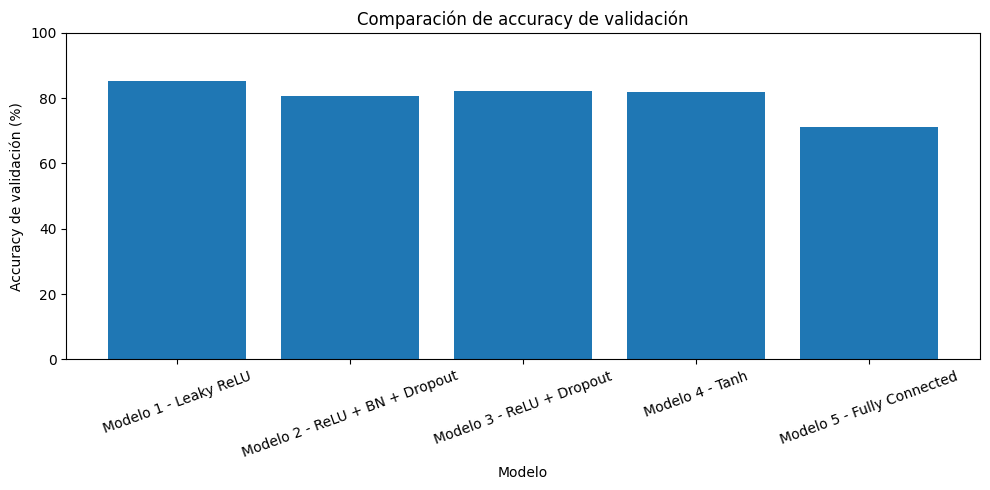

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    comparacion_modelos["Modelo"],
    comparacion_modelos["Accuracy validación"]
)

plt.ylabel("Accuracy de validación (%)")
plt.xlabel("Modelo")
plt.title("Comparación de accuracy de validación")
plt.xticks(rotation=20)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

### Análisis del sobreajuste

Al revisar las curvas de entrenamiento y validación se puede observar que no todos los modelos se comportaron de la misma manera.

En el Modelo 1, la accuracy de validación llegó a 85.39% y mostró una mejora durante el entrenamiento. Aunque existe una diferencia entre la precisión de entrenamiento y la de validación, no se observa un crecimiento tan marcado como en otros modelos.

En el Modelo 2 se utilizaron BatchNormalization y Dropout para ayudar a controlar el sobreajuste. Su resultado de validación fue de 80.65%.

El Modelo 3 obtuvo un 82.14% de accuracy de validación y presentó un comportamiento relativamente estable entre entrenamiento y validación.

En el Modelo 4 se observa el caso más claro de sobreajuste. La accuracy de entrenamiento aumentó hasta aproximadamente 97%, mientras que la de validación se mantuvo alrededor del 80%. Esto indica que el modelo aprendió muy bien los datos de entrenamiento, pero ese aprendizaje no se reflejó de la misma forma en los datos de validación.

En el Modelo 5, Fully Connected, la accuracy de entrenamiento terminó en 65.97% y la mejor accuracy de validación fue de 71.04%. En este caso no se observa el patrón típico de sobreajuste; más bien, el modelo tuvo un rendimiento menor que las CNN.

Por lo tanto, además de comparar la accuracy, es importante considerar el comportamiento de entrenamiento y validación. Un modelo con una accuracy alta pero con una diferencia muy grande entre ambas métricas puede estar sobreajustándose.

### Comparación de configuración

Los modelos fueron cambiando principalmente en el número de capas, la función de activación y las técnicas utilizadas para tratar de mejorar el entrenamiento.

El Modelo 1 utiliza cinco bloques convolucionales y Leaky ReLU.

El Modelo 2 también tiene cinco bloques convolucionales, pero utiliza ReLU junto con BatchNormalization y Dropout.

El Modelo 3 tiene cuatro bloques convolucionales, utiliza ReLU y Dropout. Por otro lado, el Modelo 4 utiliza cinco bloques convolucionales con Tanh.

El Modelo 5 es diferente porque no utiliza capas convolucionales. Primero aplana la imagen de 160 × 160 × 3 a 76 800 valores y después utiliza capas Dense de 512, 256 y 128 neuronas. También utiliza BatchNormalization, Leaky ReLU y Dropout.

En cuanto al optimizador, se utilizó Adam en los modelos. En el Modelo 1 y en el Modelo 5 se utilizó un learning rate de 0.0001, mientras que en los otros modelos se dejó la configuración de Adam utilizada en el cuaderno.

Con estas pruebas se pudo observar cómo los cambios en la arquitectura y en las técnicas de regularización afectan el resultado final de los modelos.

A continuación se resumen las principales configuraciones utilizadas en cada modelo:

In [ ]:
configuracion_modelos = pd.DataFrame({
    "Modelo": [
        "Modelo 1 - Leaky ReLU",
        "Modelo 2 - ReLU + BN + Dropout",
        "Modelo 3 - ReLU + Dropout",
        "Modelo 4 - Tanh",
        "Modelo 5 - Fully Connected"
    ],
    "Profundidad": [
        "5 bloques CNN",
        "5 bloques CNN",
        "4 bloques CNN",
        "5 bloques CNN",
        "Sin capas CNN"
    ],
    "Activación": [
        "Leaky ReLU",
        "ReLU",
        "ReLU",
        "Tanh",
        "Leaky ReLU"
    ],
    "Optimizador": [
        "Adam",
        "Adam",
        "Adam",
        "Adam",
        "Adam"
    ],
    "Learning rate": [
        "0.0001",
        "0.001",
        "0.001",
        "0.001",
        "0.0001"
    ],
    "Regularización": [
        "Dropout 0.5",
        "Dropout 0.5",
        "Dropout 0.5",
        "Dropout 0.5",
        "Dropout"
    ],
    "Batch Normalization": [
        "No",
        "Sí",
        "No",
        "No",
        "Sí"
    ]
})

configuracion_modelos

,Modelo,Profundidad,Activación,Optimizador,Learning rate,Regularización,Batch Normalization
0,Modelo 1 - Leaky ReLU,5 bloques CNN,Leaky ReLU,Adam,0.0001,Dropout 0.5,No
1,Modelo 2 - ReLU + BN + Dropout,5 bloques CNN,ReLU,Adam,0.001,Dropout 0.5,Sí
2,Modelo 3 - ReLU + Dropout,4 bloques CNN,ReLU,Adam,0.001,Dropout 0.5,No
3,Modelo 4 - Tanh,5 bloques CNN,Tanh,Adam,0.001,Dropout 0.5,No
4,Modelo 5 - Fully Connected,Sin capas CNN,Leaky ReLU,Adam,0.0001,Dropout,Sí


### Comportamiento durante el entrenamiento

Para complementar la comparación de las arquitecturas, se revisaron las gráficas de accuracy y pérdida obtenidas durante el entrenamiento y la validación de cada modelo. Esto permite observar cómo fue evolucionando cada modelo y detectar posibles diferencias entre el desempeño en entrenamiento y validación.

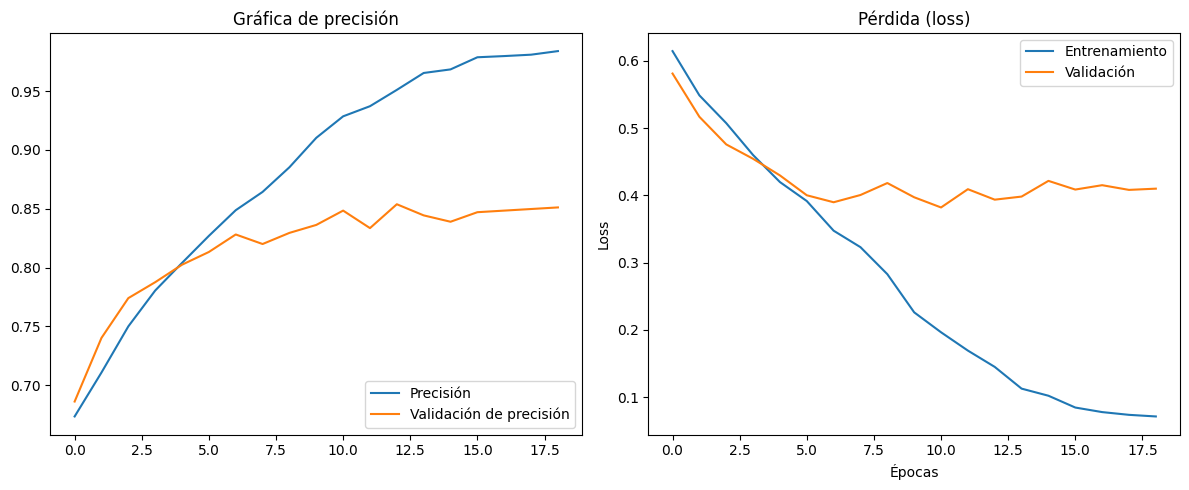

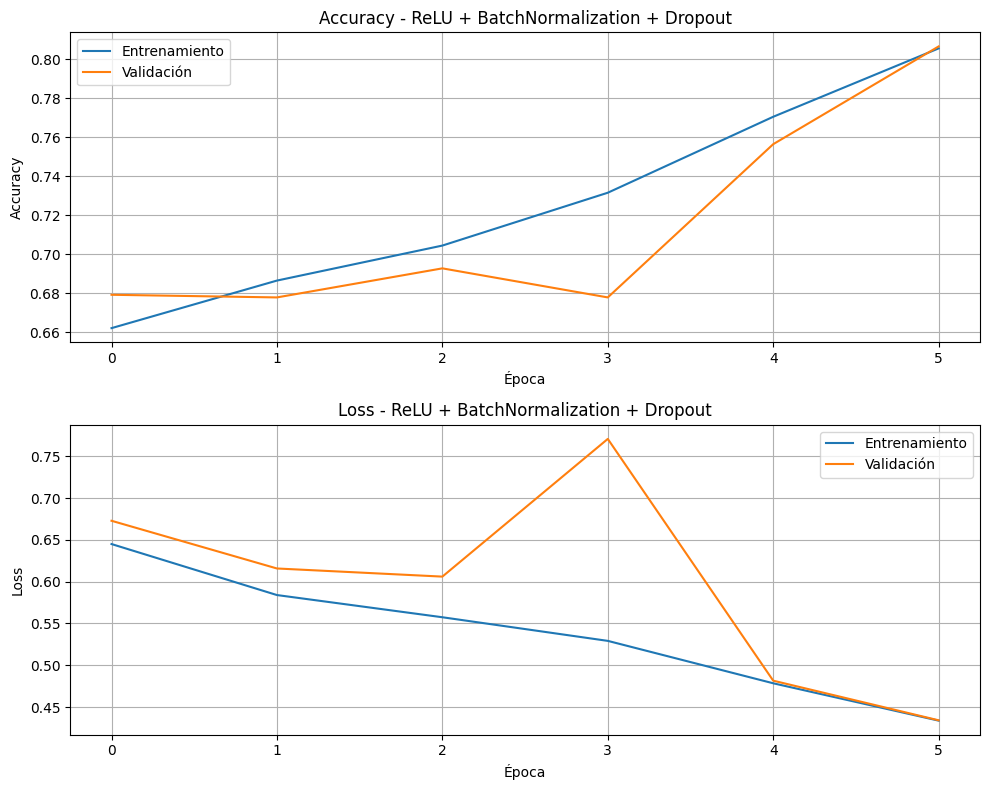

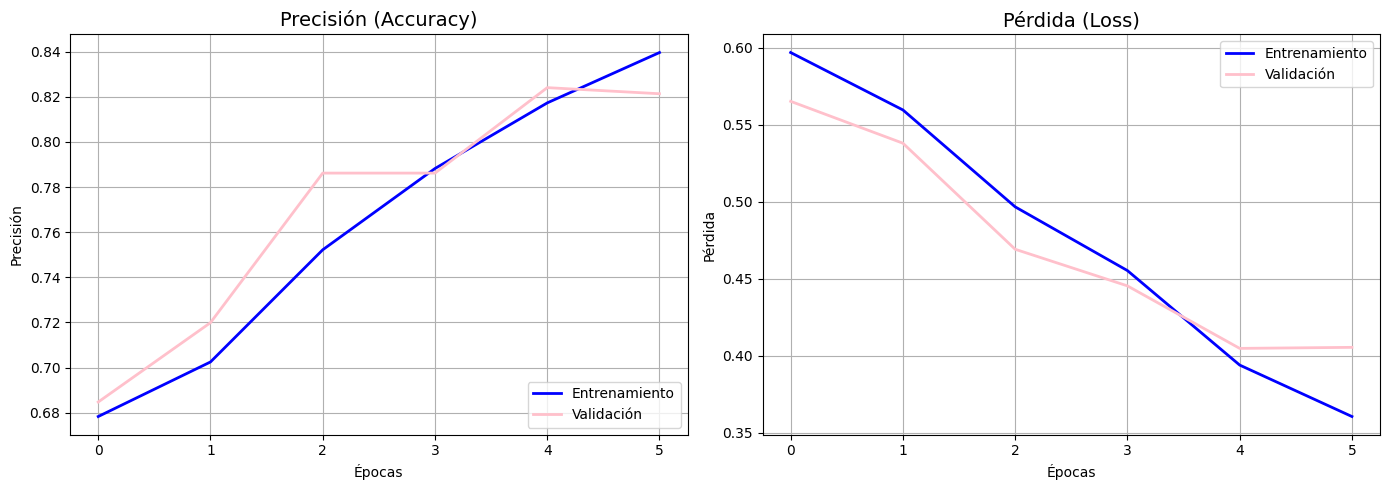


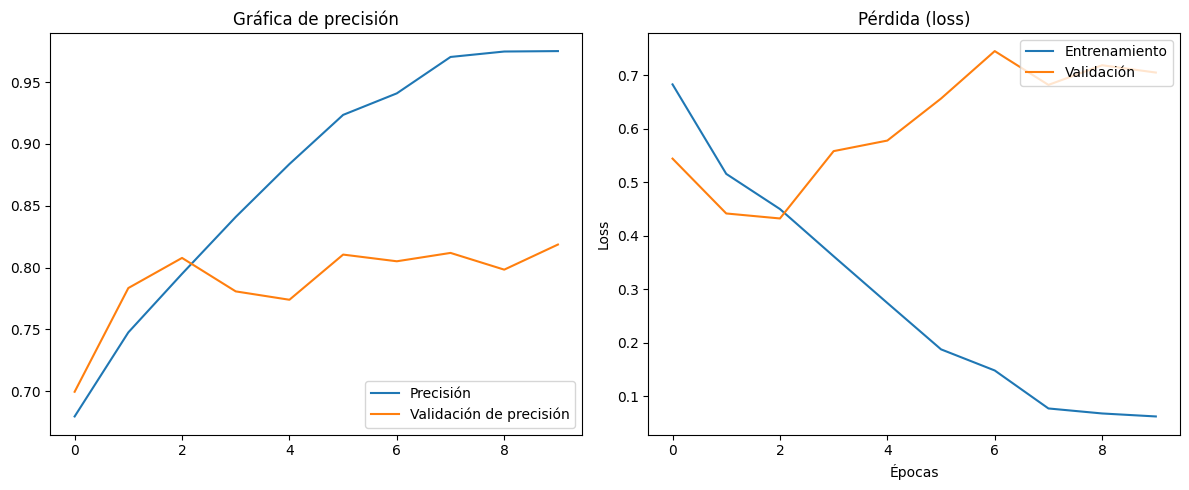

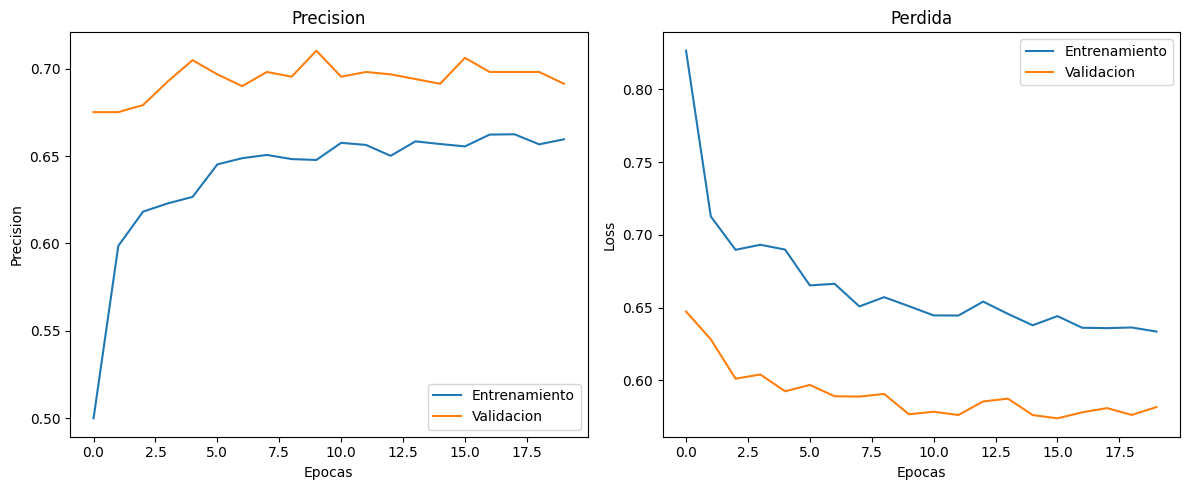

## **Conclusión**


Con esta actividad pudimos comparar diferentes modelos para identificar perros y gatos y ver cómo los cambios en la arquitectura afectan sus resultados.

Al comparar los modelos, las CNN tuvieron un mejor comportamiento que el modelo Fully Connected. También pudimos observar que utilizar diferentes funciones de activación, Dropout y BatchNormalization puede cambiar bastante el resultado.

El Modelo 1 obtuvo el mejor resultado de validación entre los modelos comparados, aunque también se pudo observar cierta diferencia entre el entrenamiento y la validación. En otros modelos se presentó un sobreajuste más evidente, como en el Modelo 4.

En general, esta comparación nos permitió entender que no solamente importa tener una red más grande, sino encontrar una configuración que tenga un buen rendimiento y que también pueda funcionar correctamente con imágenes que no haya visto durante el entrenamiento.